Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.4296 - loss: 1.5500 - val_accuracy: 0.5180 - val_loss: 1.3391
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.5736 - loss: 1.2005 - val_accuracy: 0.6113 - val_loss: 1.0853
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6327 - loss: 1.0436 - val_accuracy: 0.6417 - val_loss: 1.0032
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6701 - loss: 0.9425 - val_accuracy: 0.6677 - val_loss: 0.9581
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.6936 - loss: 0.8757 - val_accuracy: 0.6768 - val_loss: 0.9460
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.7093 - loss: 0.8221 - val_accuracy: 0.6841 - val_loss: 0.9096
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7290 - loss: 0.7735 - val_accuracy: 0.6884 - val_loss: 0.9023
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.7431 -

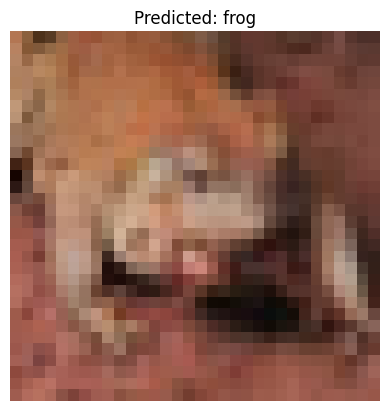

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

model = models.Sequential ([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10) # 10 classes
])

model.compile(optimizer = 'adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test,y_test))

test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 2)
print('Test Accuracy:', test_acc)

probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(x_test)

def show_prediction(index):
  plt.imshow(x_test[index])
  plt.title(f"Predicted: {class_names[np.argmax(predictions[index])]}")
  plt.axis('off')
  plt.show()

show_prediction(5)